## Annual Temperature in Australia 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os



In [4]:
DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

df = pd.read_csv(os.path.join(DATA_DIR, "temp", "20210908_cli_001_graph-forplot.csv")) # From data.gov.au

print(df.head(), df.tail())

   Year  Temperature  11-year mean  Unnamed: 3   Pyear     P   Nyear     N
0  1910        -0.50           NaN         NaN  1914.0  0.12  1910.0 -0.50
1  1911        -0.68           NaN         NaN  1915.0  0.07  1911.0 -0.68
2  1912        -0.20           NaN         NaN  1928.0  0.16  1912.0 -0.20
3  1913        -0.87           NaN         NaN  1938.0  0.19  1913.0 -0.87
4  1914         0.12           NaN         NaN  1942.0  0.08  1916.0 -0.57      Year  Temperature  11-year mean  Unnamed: 3  Pyear   P  Nyear   N
106  2016         0.99           NaN         NaN    NaN NaN    NaN NaN
107  2017         1.06           NaN         NaN    NaN NaN    NaN NaN
108  2018         1.12           NaN         NaN    NaN NaN    NaN NaN
109  2019         1.52           NaN         NaN    NaN NaN    NaN NaN
110  2020         1.15           NaN         NaN    NaN NaN    NaN NaN


In [5]:
print(df.columns)

Index(['Year', 'Temperature', '11-year mean', 'Unnamed: 3', 'Pyear', 'P',
       'Nyear', 'N'],
      dtype='object')


In [6]:
df = df.dropna(subset=["Year", "Temperature"])


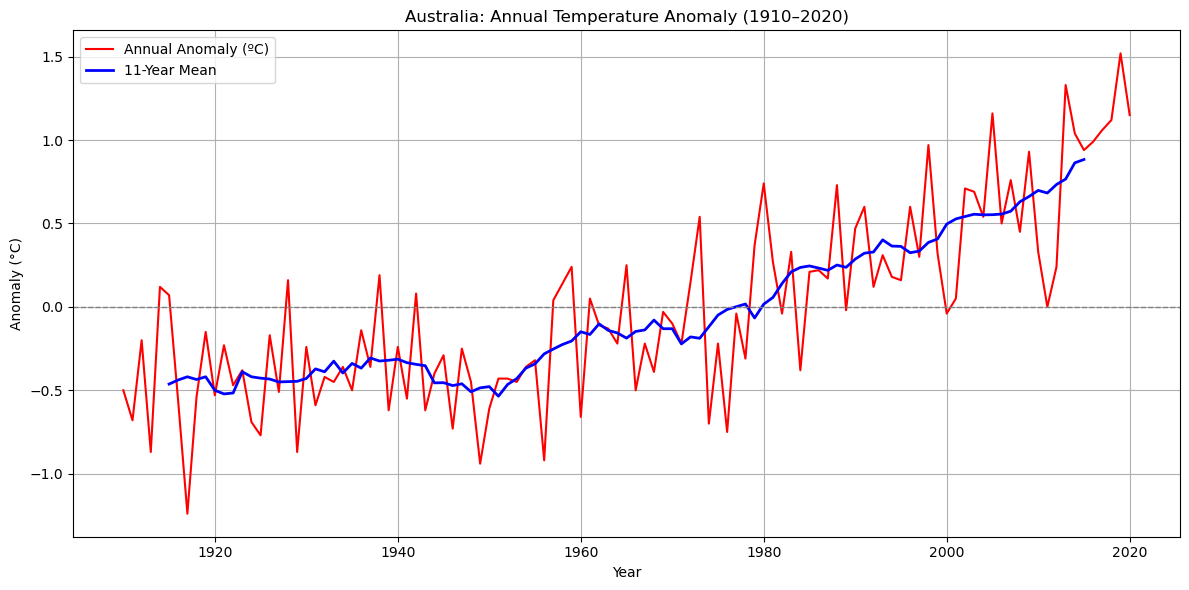

In [7]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Temperature'], label="Annual Anomaly (ºC)", color="red")
plt.plot(df["Year"], df["11-year mean"], label="11-Year Mean", color="blue", linewidth=2)

         
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Australia: Annual Temperature Anomaly (1910–2020)")
plt.xlabel("Year")
plt.ylabel("Anomaly (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
df_cleaned_temperature = pd.read_csv(os.path.join(DATA_DIR, "temp", "australia_annual_mean_temp_clean.csv"))

df_cleaned_temperature.set_index("Year", inplace=True)

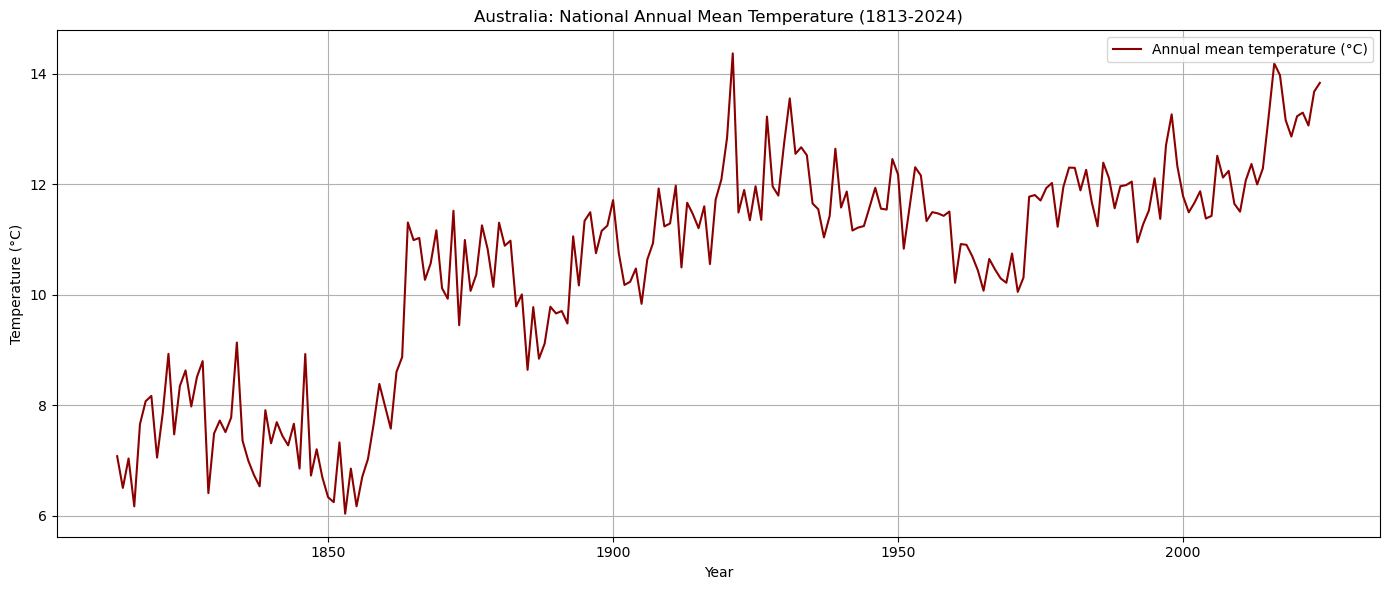

In [11]:
df_cleaned_temperature["Australia Mean Temp (°C)"].plot(
    figsize=(14, 6),
    color="darkred",
    label="Annual mean temperature (°C)",
    title="Australia: National Annual Mean Temperature (1813-2024)")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.savefig(os.path.join(OUTPUTS_DIR, "aus_mean_temp_solo.png"), dpi=300)
plt.legend()
plt.tight_layout()
plt.show()


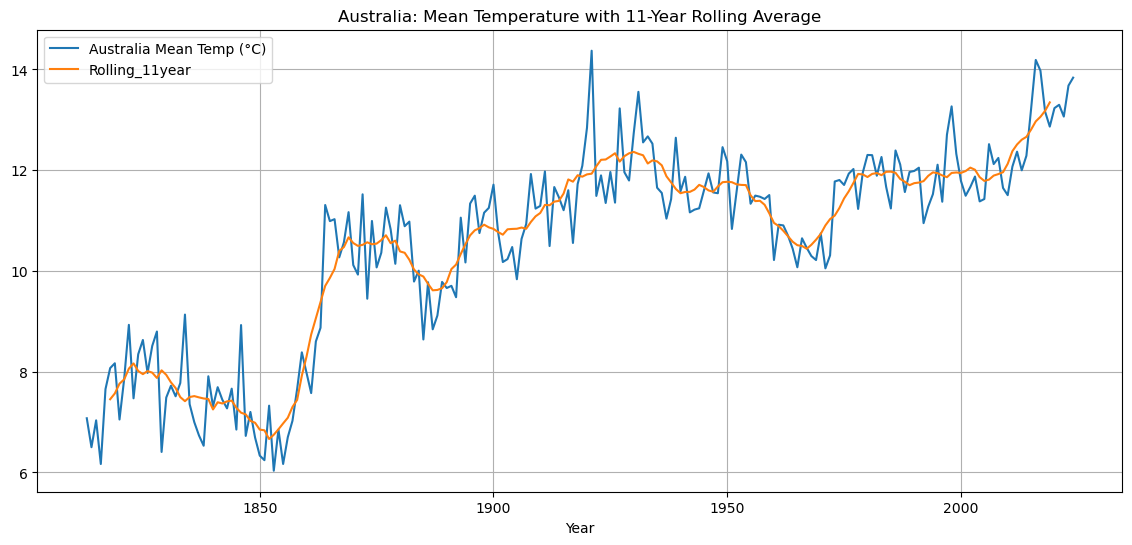

In [10]:
# Rolling Average 11-year
df_cleaned_temperature["Rolling_11year"] = df_cleaned_temperature["Australia Mean Temp (°C)"].rolling(window=11, center=True).mean()
df_cleaned_temperature[["Australia Mean Temp (°C)", "Rolling_11year"]].plot(figsize=(14, 6))
plt.title("Australia: Mean Temperature with 11-Year Rolling Average")
plt.grid(True)
plt.savefig(os.path.join(OUTPUTS_DIR, "aus_temp_trend.png"), dpi=300)
plt.show()